In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Rescaling
import matplotlib.pyplot as plt

import keras,os
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten, Dropout
import numpy as np

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# dataset_dir = '/content/drive/MyDrive/AI_Pics/Leaf Dataset'
dataset_dir = '/Users/sumitkumar/Desktop/VSCode/LPU/SEM2/AI/CNN/Project-Final/Leaf-Dataset'

In [4]:
batch_size = 32
img_height = 200
img_width = 300
epochs = 20

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.1,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 300 files belonging to 6 classes.
Using 270 files for training.
Found 300 files belonging to 6 classes.
Using 30 files for validation.


In [6]:
class_names = train_ds.class_names
class_names

['Basil', 'Chinar', 'Guava', 'Jamun', 'Lemon', 'Mango']

2026-04-25 12:04:11.048098: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


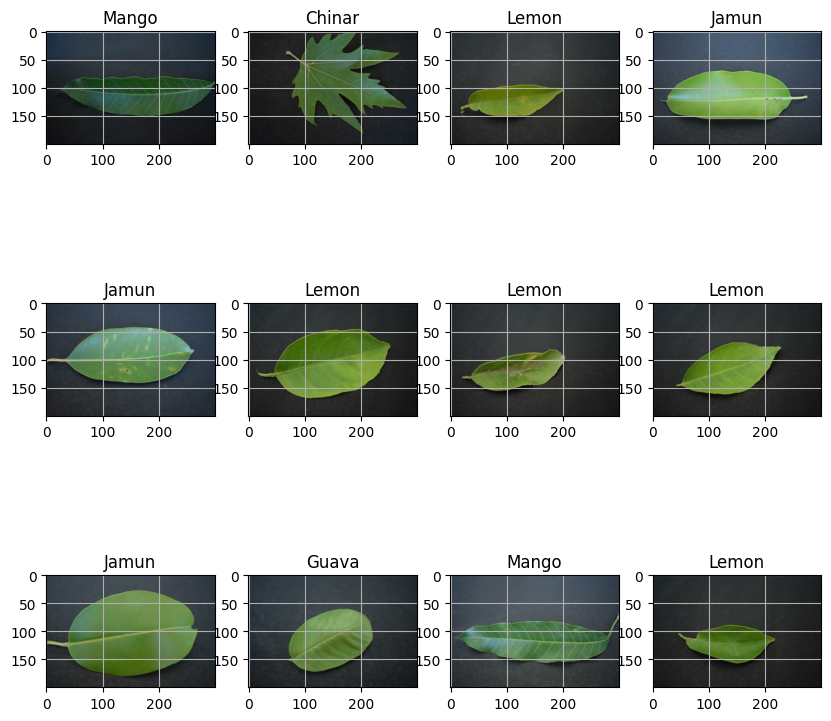

In [7]:
# plt.figure(figsize=(10, 10))
# for images, labels in train_ds.take(1):
#   for i in range(9):
#     ax = plt.subplot(3, 3, i + 1)
#     plt.imshow(images[i].numpy().astype("uint8"))
#     plt.title(class_names[labels[i]])
#     plt.axis("off")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.grid(True)

In [8]:
model = Sequential([
Rescaling(1./255, input_shape=(img_height, img_width, 3)),
Conv2D(30, 3, activation='relu'),
MaxPooling2D(),
Conv2D(30, 3, activation='relu'),
MaxPooling2D(),
Conv2D(20, 3, activation='relu'),
MaxPooling2D(),
# Dropout(0.2),
Flatten(),
Dense(64, activation='relu'),
Dense(128, activation='relu'),
Dense(len(class_names), activation='softmax')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE),
              metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 298, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 149, 30)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 147, 30)    │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 73, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 71, 20)     │         5,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 35, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16100)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,030,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,948 (4.02 MB)

 Trainable params: 1,053,948 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs = epochs
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 304ms/step - accuracy: 0.1926 - loss: 1.8043 - val_accuracy: 0.0667 - val_loss: 1.7975
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - accuracy: 0.3037 - loss: 1.7111 - val_accuracy: 0.0667 - val_loss: 1.7332
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.4185 - loss: 1.4585 - val_accuracy: 0.7000 - val_loss: 1.2280
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.6741 - loss: 0.9562 - val_accuracy: 0.5667 - val_loss: 0.9466
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 0.6889 - loss: 0.7653 - val_accuracy: 0.7667 - val_loss: 0.4986
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.8407 - loss: 0.4792 - val_accuracy: 0.8333 - val_loss: 0.3779
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.8963 - loss: 0.3069 - val_accuracy: 0.9667 - val_loss: 0.2425
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.9333 - loss: 0.2197 - val_accuracy: 0.9667 - val_loss:

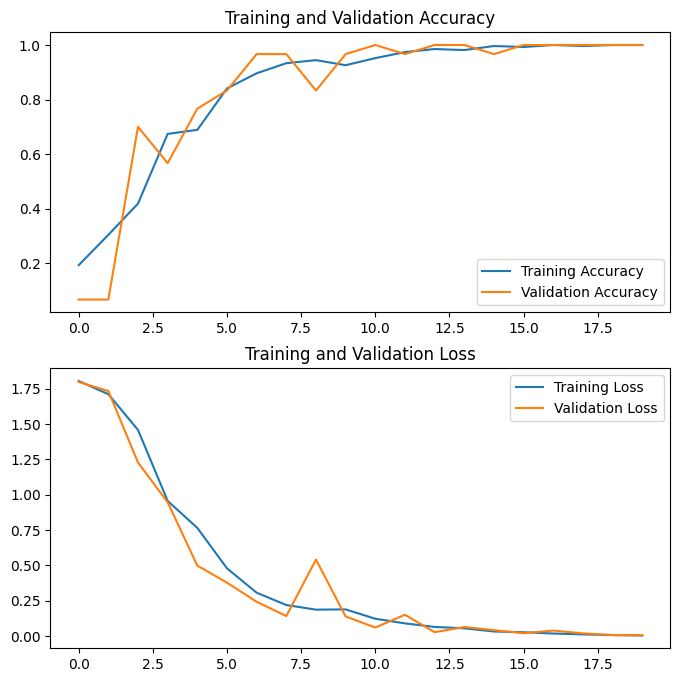

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [13]:
# Display the maximum validation accuracy
print(f"Maximum Validation Accuracy: {max(val_acc)*100:.2f}%")

Maximum Validation Accuracy: 100.00%


In [14]:
# Display the maximum validation loss
print(f"Maximum Validation Loss: {min(val_loss)*100:.2f}%")

Maximum Validation Loss: 0.69%


In [15]:
test_loss, test_acc = model.evaluate(train_ds)
print(f'Test Loss: {test_loss * 100:.2f}%')
print(f'Test Accuracy: {test_acc * 100:.2f}%')

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 0.0020
Test Loss: 0.20%
Test Accuracy: 100.00%


In [16]:
print(model.evaluate(val_ds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 1.0000 - loss: 0.0069
[0.006941924337297678, 1.0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


2026-04-25 12:05:06.984161: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


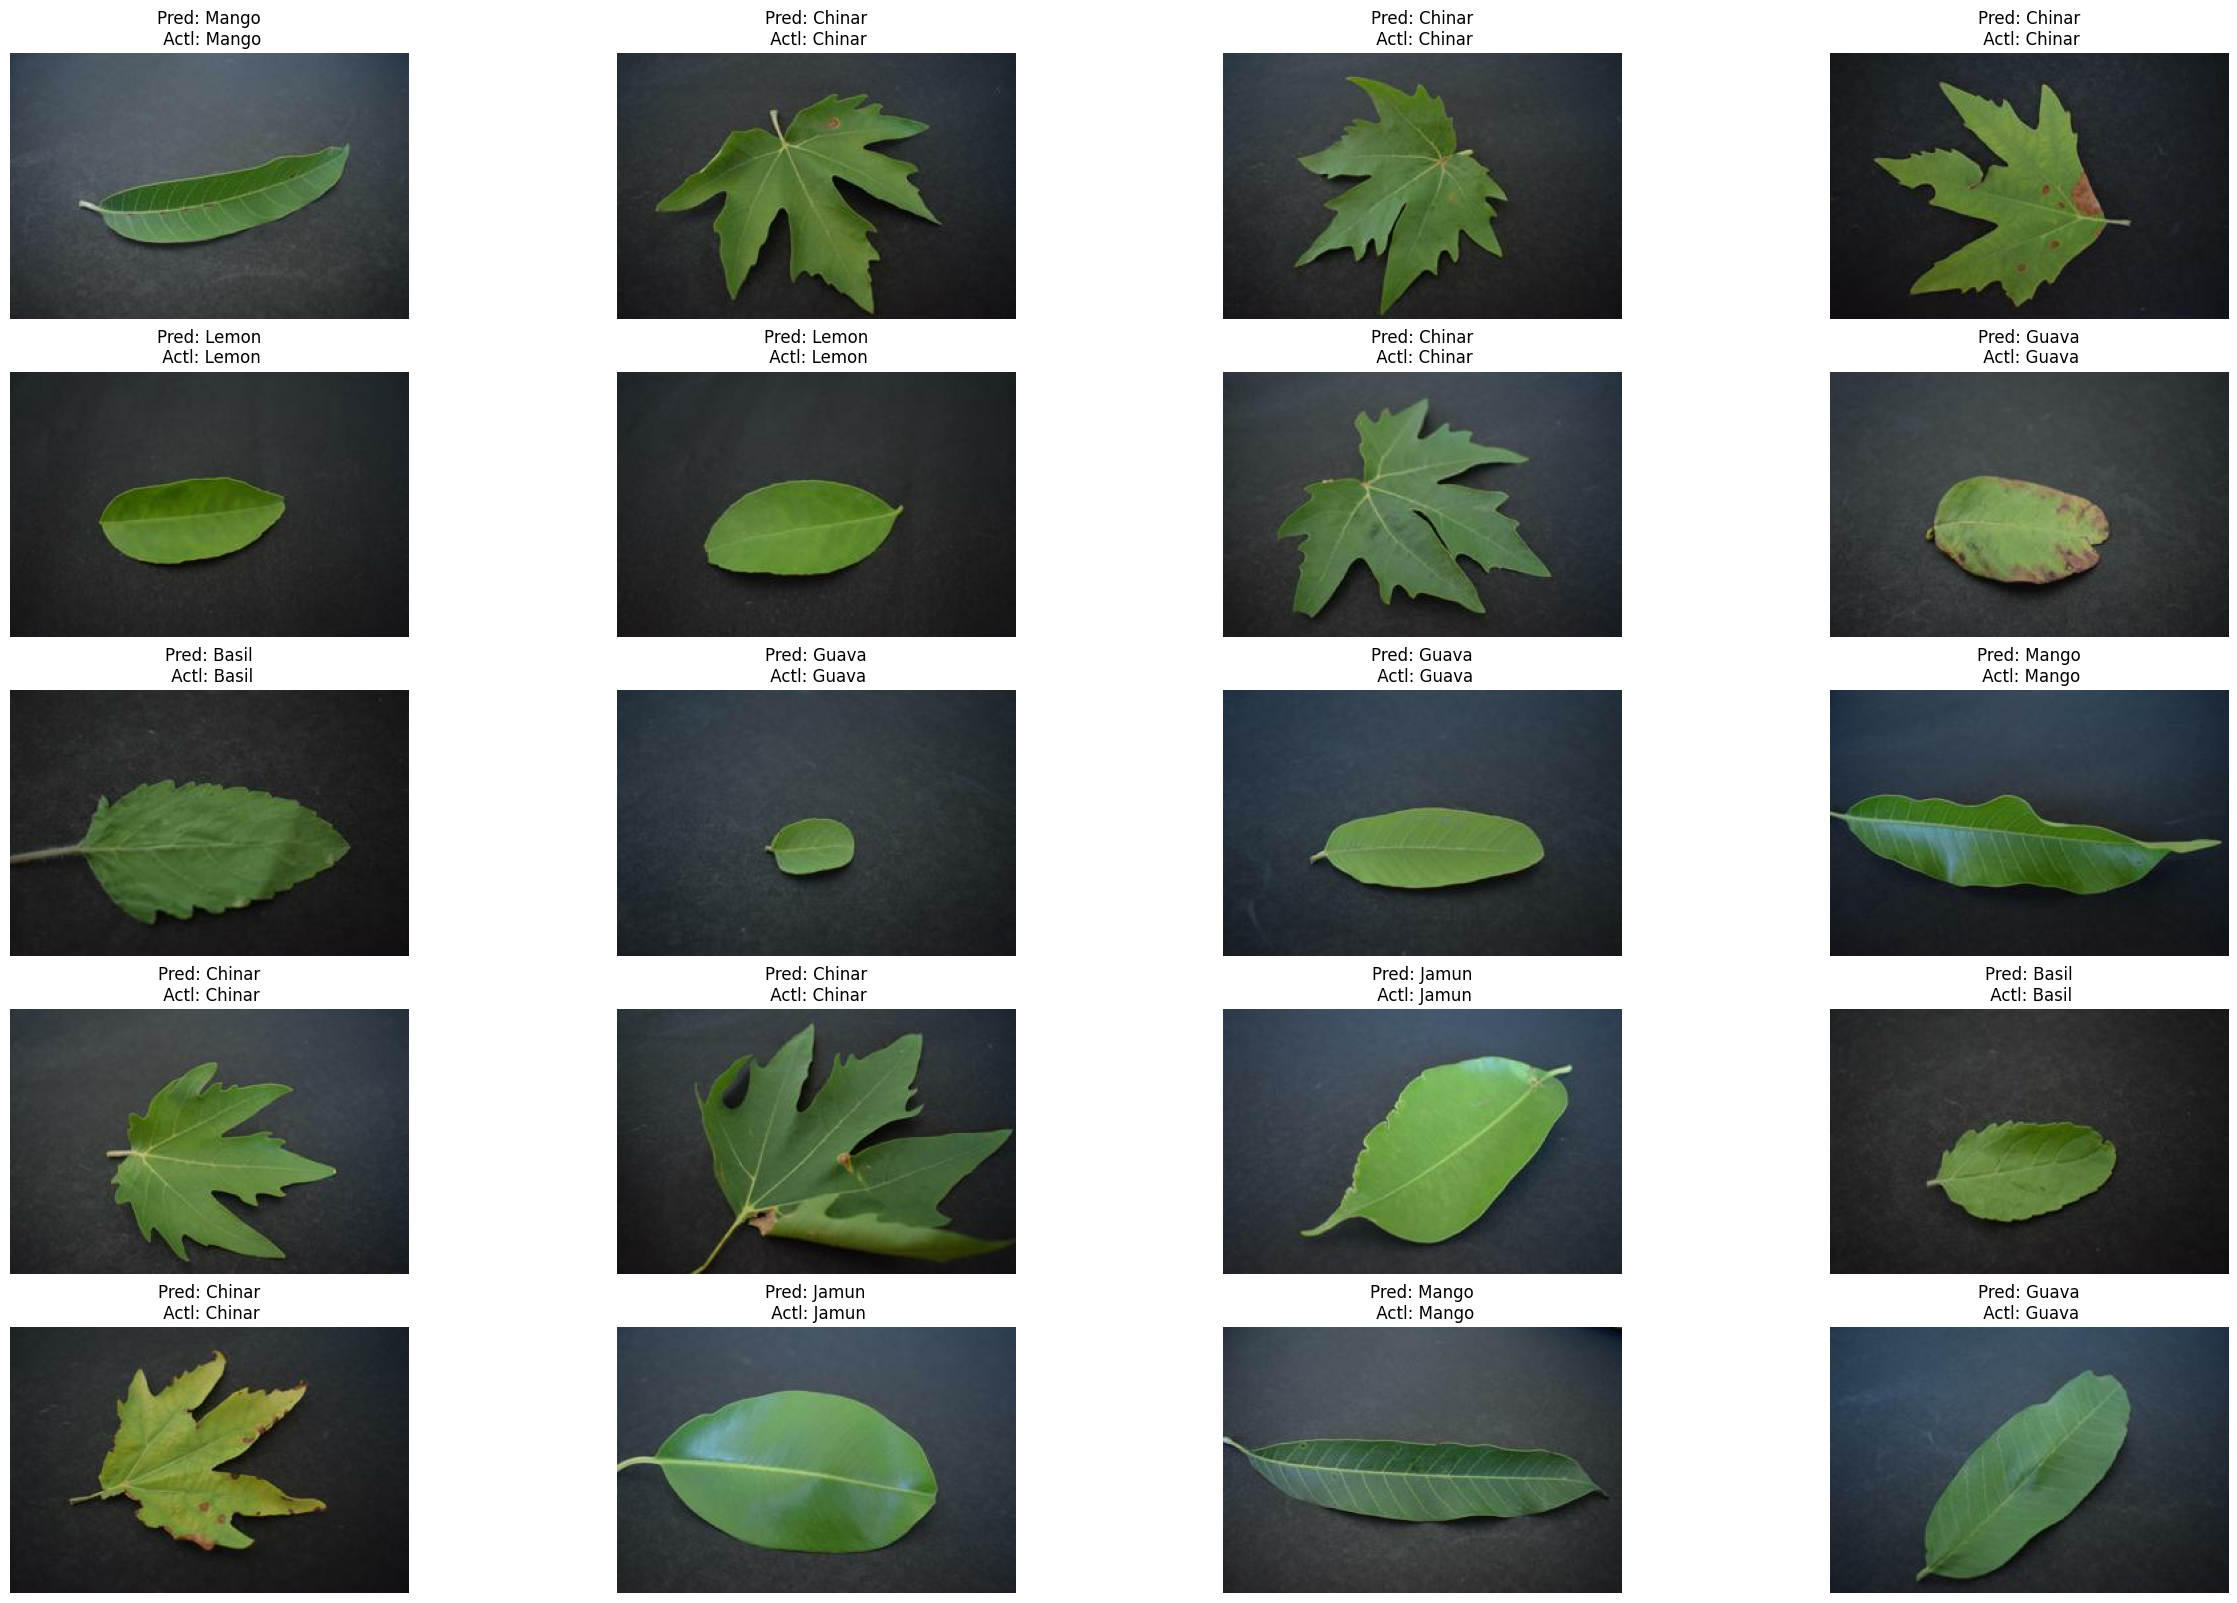

In [17]:
AccuracyVector = []
plt.figure(figsize=(30, 20))
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predlabel = []
    prdlbl = []

    for mem in predictions:
        predlabel.append(class_names[np.argmax(mem)])
        prdlbl.append(np.argmax(mem))

    AccuracyVector = np.array(prdlbl) == labels
    for i in range(20):
        ax = plt.subplot(5, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title('Pred: '+ predlabel[i] + '\n Actl: '+ class_names[labels[i]])
        plt.axis('off')
        plt.grid(True)

In [21]:
model.save('plantclassificationmodelbest.h5',include_optimizer=True)

In [19]:
# from google.colab import files
# files.download("plantclassificationmodel.h5")